In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
column_names = [
    "First Term Gpa",
    "Second Term Gpa",
    "First Language",
    "Funding",
    "School",
    "FastTrack",
    "Coop",
    "Residency",
    "Gender",
    "Previous Education",
    "Age Group",
    "High School Average Mark",
    "Math Score",
    "English Grade",
    "FirstYearPersistence"
]

df = pd.read_csv("Student data (1).csv", skiprows=25, header=None)
df.columns = column_names

In [13]:
df.replace("?", np.nan, inplace=True)

In [14]:
numeric_cols = [
    "First Term Gpa",
    "Second Term Gpa",
    "High School Average Mark",
    "Math Score",
    "English Grade"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

In [15]:
# Mean for continuous variables
df["First Term Gpa"] = df["First Term Gpa"].fillna(df["First Term Gpa"].mean())
df["Second Term Gpa"] = df["Second Term Gpa"].fillna(df["Second Term Gpa"].mean())

# Median for skewed variables
df["High School Average Mark"] = df["High School Average Mark"].fillna(df["High School Average Mark"].median())
df["Math Score"] = df["Math Score"].fillna(df["Math Score"].median())

# Mode for categorical-like variable
df["English Grade"] = df["English Grade"].fillna(df["English Grade"].mode()[0])

# Categorical columns
categorical_cols = [
    "First Language",
    "Funding",
    "School",
    "FastTrack",
    "Coop",
    "Residency",
    "Gender",
    "Previous Education",
    "Age Group"
]

# Fill missing categorical values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [16]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [17]:
df.columns = df.columns.str.replace(" ", "_")

In [18]:
numeric_cols = [
    "First_Term_Gpa",
    "Second_Term_Gpa",
    "High_School_Average_Mark",
    "Math_Score",
    "English_Grade"
]

In [19]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

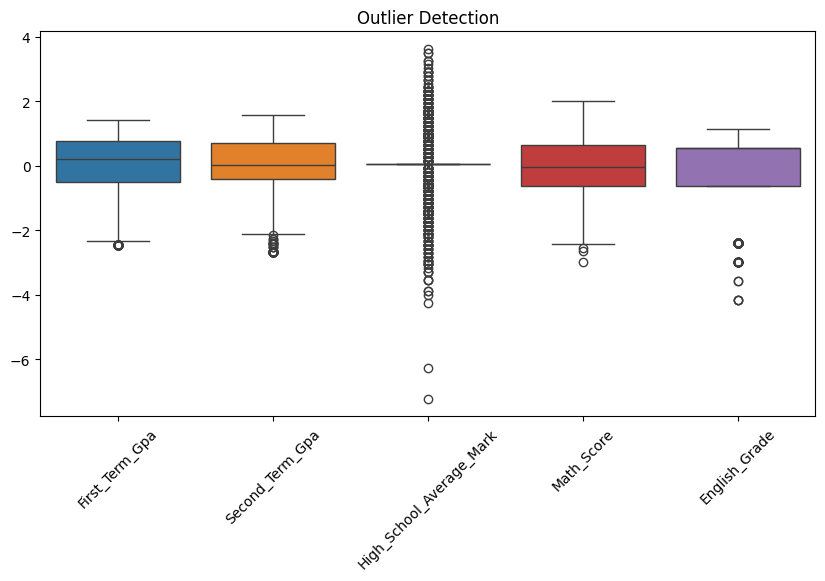

In [20]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()

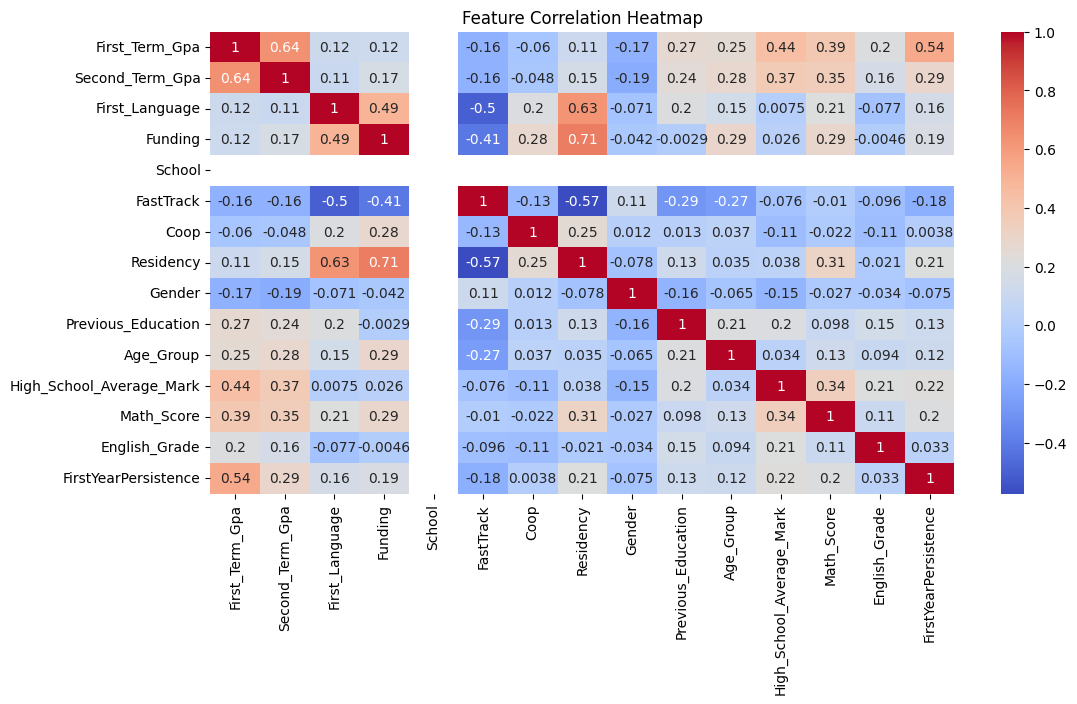

In [21]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [22]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   First_Term_Gpa  Second_Term_Gpa  First_Language  Funding  School  \
0       -0.298600        -0.774892               2        2       0   
1        1.202641         1.037125               0        0       0   
2        0.148198        -0.472026               2        2       0   
3        1.224087         1.417649               0        1       0   
4        1.294553         1.416861               0        1       0   

   FastTrack  Coop  Residency  Gender  Previous_Education  Age_Group  \
0          0     1          1       1                   1          2   
1          1     0          0       0                   2          2   
2          0     1          1       1                   2          2   
3          0     0          0       0                   2          2   
4          1     0          0       1                   2          2   

   High_School_Average_Mark  Math_Score  English_Grade  FirstYearPersistence  
0                  0.047266   -0.044248      -0.625296       